# ECG + EDA 情绪识别入门教学 Notebook（Colab 最终版）

这个版本已经按你的目录结构写好了：

```text
MyDrive/
└── emotion_classification/
    ├── ECG_EDA_WESAD_emotion_tutorial_COLAB_FINAL.ipynb
    └── WESAD/
        ├── S2/
        │   └── S2.pkl
        ├── S3/
        │   └── S3.pkl
        └── ...
```

也就是说：

- notebook 放在 `emotion_classification`
- 数据集 `WESAD` 也放在 `emotion_classification`
- 两者并列

所以这份 notebook 默认路径就是：

```python
/content/drive/MyDrive/emotion_classification/WESAD
```

---

## 这份 notebook 适合什么场景？
它适合你现在这种教学目标：

1. 学会 ECG / EDA 的标准预处理流程  
2. 学会从连续信号切窗  
3. 学会提手工特征  
4. 学会做一个最基础的 RandomForest baseline  
5. 最后能看懂一条完整的情绪识别 / 压力识别 pipeline

In [2]:
# ====== 第 0 步：安装依赖（Colab 第一次运行时执行） ======
!pip -q install neurokit2 pandas numpy matplotlib scikit-learn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 14.7 MB/s eta 0:00:00


In [3]:
# ====== 第 1 步：挂载 Google Drive ======
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 第 2 步：设置项目路径

这里已经按你的目录结构设置好默认值：

```text
/content/drive/MyDrive/emotion_classification/WESAD
```

如果你的 `emotion_classification` 就在 MyDrive 根目录下，下面通常不用改。

In [4]:
from pathlib import Path
import shutil
import os
import pickle

# ====== 按你的目录结构写好的默认路径 ======
PROJECT_ROOT = Path("/content/drive/MyDrive/emotion_classification")
DRIVE_DATA_ROOT = PROJECT_ROOT / "WESAD" / "WESAD"

# 先从一个被试开始
SUBJECT = "S2"

drive_subject_file = DRIVE_DATA_ROOT / SUBJECT / f"{SUBJECT}.pkl"

print("PROJECT_ROOT        :", PROJECT_ROOT)
print("DRIVE_DATA_ROOT     :", DRIVE_DATA_ROOT)
print("Drive subject file  :", drive_subject_file)
print("Project exists?     :", PROJECT_ROOT.exists())
print("WESAD exists?       :", DRIVE_DATA_ROOT.exists())
print("Subject file exists?:", drive_subject_file.exists())

PROJECT_ROOT        : /content/drive/MyDrive/emotion_classification
DRIVE_DATA_ROOT     : /content/drive/MyDrive/emotion_classification/WESAD/WESAD
Drive subject file  : /content/drive/MyDrive/emotion_classification/WESAD/WESAD/S2/S2.pkl
Project exists?     : True
WESAD exists?       : True
Subject file exists?: True


## 第 3 步：推荐复制到 `/content` 再运行

虽然可以直接从 Google Drive 挂载路径读取数据，  
但对信号处理任务来说，把当前要用的 `.pkl` 复制到 Colab 本地 `/content` 一般更稳。

这里默认开启。

In [5]:
# ====== 推荐：复制到 Colab 本地临时目录 ======
USE_LOCAL_COPY = True

if USE_LOCAL_COPY:
    local_root = Path("/content/WESAD")
    local_subject_dir = local_root / SUBJECT
    local_subject_dir.mkdir(parents=True, exist_ok=True)

    local_subject_file = local_subject_dir / f"{SUBJECT}.pkl"
    shutil.copy2(drive_subject_file, local_subject_file)

    subject_file = local_subject_file
    print("Copied to local runtime:", subject_file)
else:
    subject_file = drive_subject_file
    print("Using file directly from Drive:", subject_file)

print("Final subject_file:", subject_file)

Copied to local runtime: /content/WESAD/S2/S2.pkl
Final subject_file: /content/WESAD/S2/S2.pkl


# 正式教学内容开始

下面开始是完整的教学流程：  
读取单个被试 → 看原始波形 → 做 ECG 和 EDA 预处理 → 切窗 → 提特征 → 做分类。

In [6]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neurokit2 as nk

from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

## 第 2 部分：读取一个 subject 的原始数据

WESAD 的 `.pkl` 文件一般是一个字典，核心字段常见包括：

- `subject`
- `signal`
- `label`

其中 `signal` 里通常又有：
- `chest`
- `wrist`

我们这份 notebook 先只用 **chest**，因为它包含 ECG。

In [7]:
with open(subject_file, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("Top-level keys:", data.keys())
print("Signal keys:", data["signal"].keys())
print("Chest keys:", data["signal"]["chest"].keys())
print("Label shape:", np.array(data["label"]).shape)

Top-level keys: dict_keys(['signal', 'label', 'subject'])
Signal keys: dict_keys(['chest', 'wrist'])
Chest keys: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
Label shape: (4255300,)


## 第 3 部分：取出 ECG / EDA / TEMP / label

### 这里的原理
我们现在只保留和“教学版情绪识别”最相关的通道：

- `ECG`：心电信号
- `EDA`：皮电信号
- `TEMP`：温度信号
- `label`：状态标签

WESAD 常见标签含义：
- `1`：baseline / neutral
- `2`：stress
- `3`：amusement

其他标签这里先不使用。

In [8]:
# WESAD chest device 的常见采样率是 700 Hz
SAMPLING_RATE = 700

ecg = np.asarray(data["signal"]["chest"]["ECG"]).squeeze()
eda = np.asarray(data["signal"]["chest"]["EDA"]).squeeze()
temp = np.asarray(data["signal"]["chest"]["Temp"]).squeeze()
labels = np.asarray(data["label"]).squeeze()

print("ECG shape :", ecg.shape)
print("EDA shape :", eda.shape)
print("TEMP shape:", temp.shape)
print("Labels    :", labels.shape)

ECG shape : (4255300,)
EDA shape : (4255300,)
TEMP shape: (4255300,)
Labels    : (4255300,)


In [9]:
# 合成一个 DataFrame 方便观察
df = pd.DataFrame({
    "ECG": ecg,
    "EDA": eda,
    "TEMP": temp,
    "label": labels
})

# 只保留 1/2/3 三种状态
df = df[df["label"].isin([1, 2, 3])].reset_index(drop=True)

label_map = {
    1: "baseline",
    2: "stress",
    3: "amusement"
}
df["label_name"] = df["label"].map(label_map)

print(df.head())
print(df["label_name"].value_counts())

        ECG       EDA       TEMP  label label_name
0  0.030945  5.710983  29.083618      1   baseline
1  0.033646  5.719376  29.122437      1   baseline
2  0.033005  5.706406  29.115234      1   baseline
3  0.031815  5.712509  29.126709      1   baseline
4  0.030350  5.727005  29.100861      1   baseline
label_name
baseline     800800
stress       430500
amusement    253400
Name: count, dtype: int64


In [10]:
# ====== 诊断 1：原始时间点数统计 ======

total_points = len(df)
total_seconds = total_points / SAMPLING_RATE
total_minutes = total_seconds / 60

print(f"当前被试: {SUBJECT}")
print(f"原始时间点数: {total_points:,}")
print(f"总时长: {total_seconds:.2f} 秒 = {total_minutes:.2f} 分钟")
print()

# 只看三类标签 1/2/3 的时长
for label_id, label_name in label_map.items():
    n_points = (df["label"] == label_id).sum()
    n_seconds = n_points / SAMPLING_RATE
    n_minutes = n_seconds / 60
    print(f"{label_name:10s} | 点数: {n_points:,} | 时长: {n_seconds:.2f} 秒 = {n_minutes:.2f} 分钟")

print("\n" + "=" * 60)

当前被试: S2
原始时间点数: 1,484,700
总时长: 2121.00 秒 = 35.35 分钟

baseline   | 点数: 800,800 | 时长: 1144.00 秒 = 19.07 分钟
stress     | 点数: 430,500 | 时长: 615.00 秒 = 10.25 分钟
amusement  | 点数: 253,400 | 时长: 362.00 秒 = 6.03 分钟



## 第 4 部分：先看原始信号

### 为什么要先画图？
因为在做任何预处理之前，你要先学会“看波形”：

- ECG 是否有明显周期？
- EDA 是否有缓慢漂移？
- TEMP 是否比较平滑？
- 标签切换时，信号有没有趋势变化？

下面先截取一小段画图。

## 第 11.5 部分：诊断切窗结果

In [12]:
# 此单元格原有的切窗诊断代码已被移动到 `features_df` 定义之后。

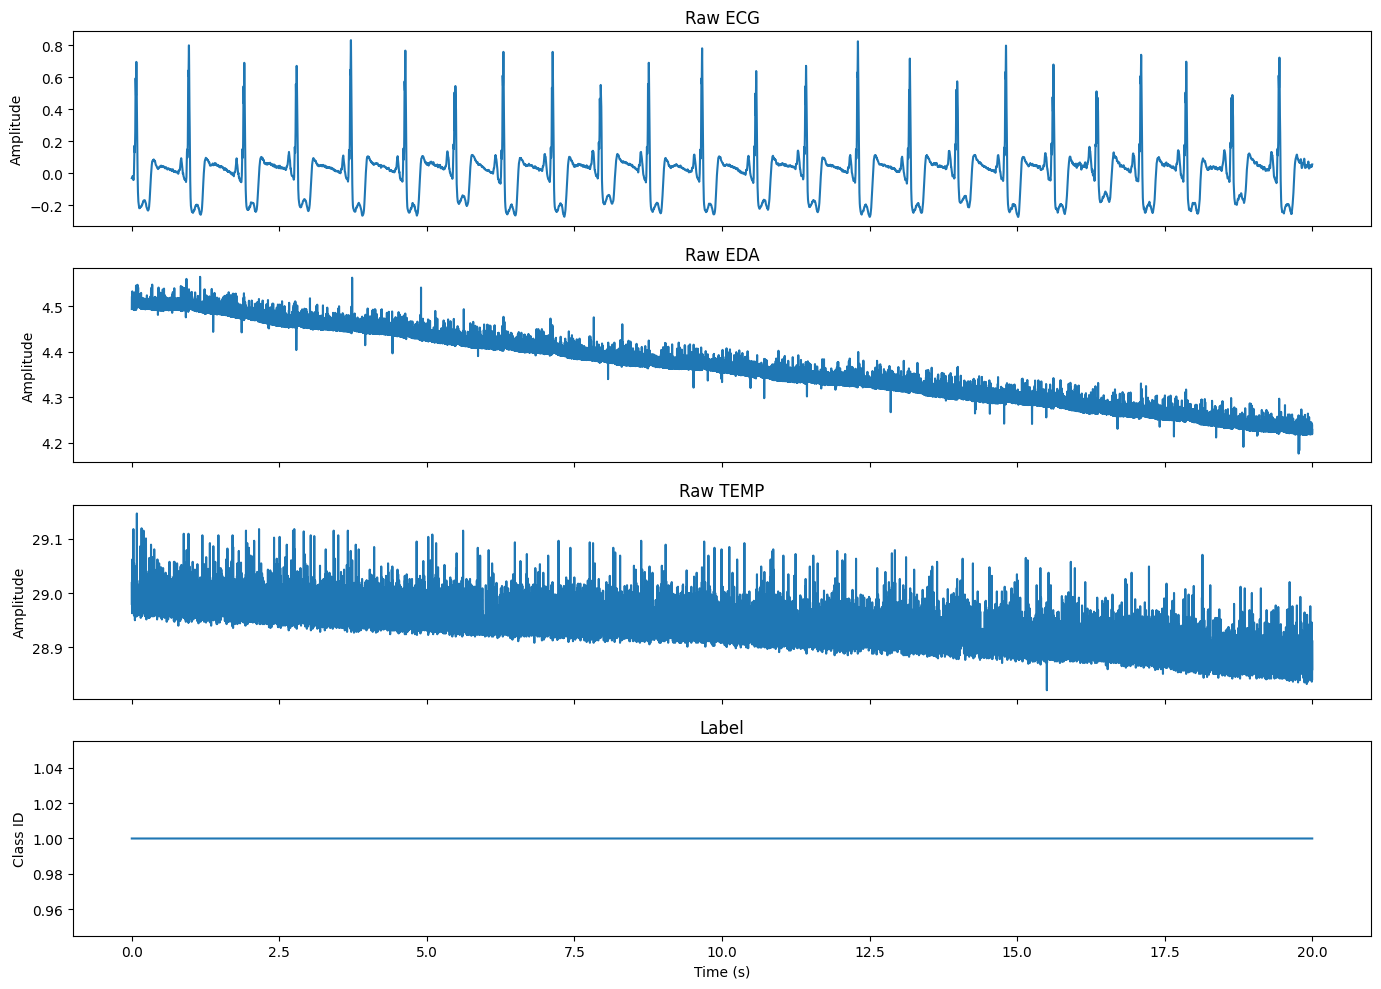

In [ ]:
def plot_raw_segment(df, start_sec=0, duration_sec=20, sampling_rate=700):
    start = int(start_sec * sampling_rate)
    end = int((start_sec + duration_sec) * sampling_rate)
    seg = df.iloc[start:end].copy()
    t = np.arange(len(seg)) / sampling_rate

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(t, seg["ECG"].values)
    axes[0].set_title("Raw ECG")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(t, seg["EDA"].values)
    axes[1].set_title("Raw EDA")
    axes[1].set_ylabel("Amplitude")

    axes[2].plot(t, seg["TEMP"].values)
    axes[2].set_title("Raw TEMP")
    axes[2].set_ylabel("Amplitude")

    axes[3].plot(t, seg["label"].values)
    axes[3].set_title("Label")
    axes[3].set_ylabel("Class ID")
    axes[3].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()

plot_raw_segment(df, start_sec=60, duration_sec=20, sampling_rate=SAMPLING_RATE)

## 第 5 部分：ECG 预处理

### 原理解释
ECG 预处理的常见目标是：
1. 清洗噪声和漂移
2. 检测 R 峰
3. 估计瞬时心率
4. 进一步得到 RR 间期和 HRV 特征

NeuroKit2 的 `ecg_process()` 可以自动完成一条比较标准的 ECG 流程。

### 你要重点看什么？
运行后你要重点观察：
- `ECG_Clean`
- `ECG_R_Peaks`
- `ECG_Rate`

如果 R 峰位置很离谱，说明预处理或信号质量可能有问题。

In [14]:
# 先只对一小段做演示，避免整条信号一次性画图太重
demo_start_sec = 120
demo_duration_sec = 30

start = int(demo_start_sec * SAMPLING_RATE)
end = int((demo_start_sec + demo_duration_sec) * SAMPLING_RATE)

ecg_demo = df["ECG"].iloc[start:end].values

ecg_signals, ecg_info = nk.ecg_process(ecg_demo, sampling_rate=SAMPLING_RATE)

print(ecg_signals.head())
print(ecg_info.keys())

    ECG_Raw  ECG_Clean  ECG_Rate  ECG_Quality  ECG_R_Peaks  ECG_P_Peaks  \
0  0.126160   0.020797  71.29662       0.9093            0            0   
1  0.124100   0.016622  71.29662       0.9093            0            0   
2  0.120346   0.012406  71.29662       0.9093            0            0   
3  0.113754   0.008143  71.29662       0.9093            0            0   
4  0.109909   0.003846  71.29662       0.9093            0            0   

   ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  ECG_R_Onsets  ECG_R_Offsets  \
0             0              0            0             0              0   
1             0              0            0             0              0   
2             0              0            0             0              0   
3             0              0            0             0              0   
4             0              0            0             0              0   

   ECG_S_Peaks  ECG_T_Peaks  ECG_T_Onsets  ECG_T_Offsets  ECG_Phase_Atrial  \
0            0

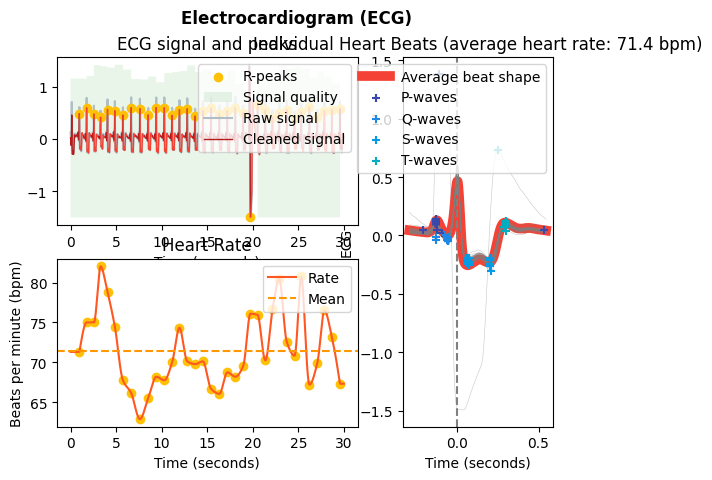

In [15]:
# 可视化 ECG 处理结果
nk.ecg_plot(ecg_signals, ecg_info)
plt.show()

## 第 6 部分：EDA 预处理

### 原理解释
EDA 常分成两部分：

- **Tonic**：慢变背景（整体水平）
- **Phasic**：快速反应（常和瞬时 arousal 相关）

你可以把它简单理解为：
> 原始 EDA = 慢背景 + 快变化 + 噪声

NeuroKit2 的 `eda_process()` 会帮你做：
- 清洗
- 分解 tonic / phasic
- SCR 峰检测

### 你要重点看什么？
- `EDA_Clean`
- `EDA_Tonic`
- `EDA_Phasic`
- `SCR_Peaks`

In [16]:
eda_demo = df["EDA"].iloc[start:end].values

eda_signals, eda_info = nk.eda_process(eda_demo, sampling_rate=SAMPLING_RATE)

print(eda_signals.head())
print(eda_info.keys())

    EDA_Raw  EDA_Clean  EDA_Tonic  EDA_Phasic  SCR_Onsets  SCR_Peaks  \
0  3.750992   3.756127   3.754200    0.001985           0          0   
1  3.757477   3.756276   3.754197    0.002137           0          0   
2  3.776169   3.756426   3.754194    0.002290           0          0   
3  3.753662   3.756576   3.754190    0.002444           0          0   
4  3.759766   3.756727   3.754187    0.002598           0          0   

   SCR_Height  SCR_Amplitude  SCR_RiseTime  SCR_Recovery  SCR_RecoveryTime  
0         0.0            0.0           0.0             0               0.0  
1         0.0            0.0           0.0             0               0.0  
2         0.0            0.0           0.0             0               0.0  
3         0.0            0.0           0.0             0               0.0  
4         0.0            0.0           0.0             0               0.0  
dict_keys(['SCR_Onsets', 'SCR_Peaks', 'SCR_Height', 'SCR_Amplitude', 'SCR_RiseTime', 'SCR_Recovery', 'SCR

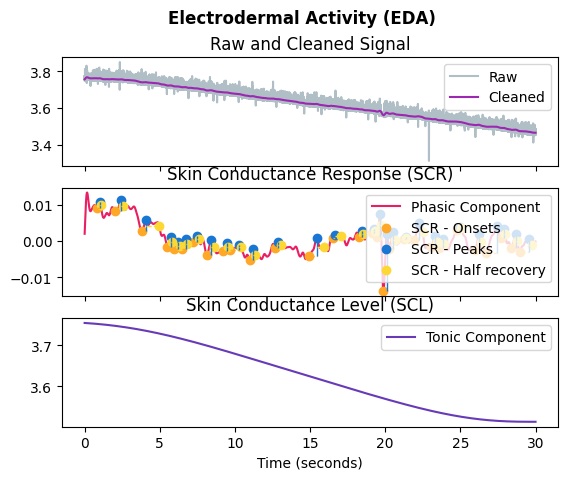

In [17]:
nk.eda_plot(eda_signals, eda_info)
plt.show()

## 第 7 部分：定义切窗函数

### 原理解释
机器学习不能直接吃“一整条很长的连续信号”，所以我们要切成窗口。

例如这里设定：
- 窗长：60 秒
- 步长：30 秒

每个窗口会生成：
- 一组 ECG 特征
- 一组 EDA 特征
- 一组 TEMP 特征
- 一个窗口标签

### 窗口标签怎么定？
这里用**窗口内最多的标签（majority vote）** 来决定这个窗口属于哪个类别。

In [18]:
WINDOW_SEC = 60
STRIDE_SEC = 30

WINDOW_SIZE = WINDOW_SEC * SAMPLING_RATE
STRIDE_SIZE = STRIDE_SEC * SAMPLING_RATE

print("WINDOW_SIZE:", WINDOW_SIZE)
print("STRIDE_SIZE:", STRIDE_SIZE)

WINDOW_SIZE: 42000
STRIDE_SIZE: 21000


In [19]:
def majority_label(y):
    values, counts = np.unique(y, return_counts=True)
    return values[np.argmax(counts)]

## 第 8 部分：自己写 ECG 特征提取函数

### 为什么不直接一步到位？
因为你现在是在学习，所以最好自己看清楚“特征是怎么来的”。

### 这里提哪些 ECG 特征？
这份教学版先提最常见的一批：

- `hr_mean`：平均心率
- `hr_std`：心率标准差
- `rr_mean_ms`：RR 间期均值
- `sdnn_ms`：RR 间期标准差
- `rmssd_ms`：相邻 RR 差分均方根
- `pnn50`：相邻 RR 间期差值超过 50ms 的比例
- `ecg_quality_mean`：信号质量平均值

### RR / HRV 的基本原理
R 峰检测出来后，两个相邻 R 峰的时间差就是 RR 间期。  
HRV（心率变异性）本质上就是在研究 RR 间期如何波动。

In [20]:
def extract_ecg_features(ecg_window, sampling_rate=700):
    try:
        signals, info = nk.ecg_process(ecg_window, sampling_rate=sampling_rate)

        heart_rate = signals["ECG_Rate"].values
        quality = signals["ECG_Quality"].values if "ECG_Quality" in signals.columns else np.full(len(signals), np.nan)

        rpeaks = np.asarray(info["ECG_R_Peaks"])
        if len(rpeaks) < 3:
            return None

        rr_ms = np.diff(rpeaks) / sampling_rate * 1000.0
        diff_rr = np.diff(rr_ms)

        feats = {
            "hr_mean": np.nanmean(heart_rate),
            "hr_std": np.nanstd(heart_rate),
            "rr_mean_ms": np.nanmean(rr_ms),
            "sdnn_ms": np.nanstd(rr_ms),
            "rmssd_ms": np.sqrt(np.nanmean(diff_rr ** 2)) if len(diff_rr) > 0 else np.nan,
            "pnn50": np.mean(np.abs(diff_rr) > 50) if len(diff_rr) > 0 else np.nan,
            "ecg_quality_mean": np.nanmean(quality),
        }
        return feats
    except Exception:
        return None

## 第 9 部分：自己写 EDA 特征提取函数

### 这里提哪些 EDA 特征？
先提最基础的一批：

- `eda_tonic_mean`
- `eda_tonic_std`
- `eda_phasic_mean`
- `eda_phasic_std`
- `scr_peak_count`
- `scr_amp_mean`

### 原理解释
- **Tonic 高低**：反映较慢的整体皮电水平
- **Phasic 波动**：反映较快的皮电活动
- **SCR 峰数量 / 幅值**：常用于表示较强的瞬时反应数量和强度

In [21]:
def extract_eda_features(eda_window, sampling_rate=700):
    try:
        signals, info = nk.eda_process(eda_window, sampling_rate=sampling_rate)

        tonic = signals["EDA_Tonic"].values
        phasic = signals["EDA_Phasic"].values

        if "SCR_Peaks" in signals.columns:
            scr_peak_mask = signals["SCR_Peaks"].values.astype(bool)
            scr_peak_count = np.sum(scr_peak_mask)
        else:
            scr_peak_mask = np.zeros(len(signals), dtype=bool)
            scr_peak_count = 0

        if "SCR_Amplitude" in signals.columns and scr_peak_count > 0:
            scr_amp_values = signals.loc[scr_peak_mask, "SCR_Amplitude"].values
            scr_amp_values = scr_amp_values[~np.isnan(scr_amp_values)]
            scr_amp_mean = np.mean(scr_amp_values) if len(scr_amp_values) > 0 else 0.0
        else:
            scr_amp_mean = 0.0

        feats = {
            "eda_tonic_mean": np.nanmean(tonic),
            "eda_tonic_std": np.nanstd(tonic),
            "eda_phasic_mean": np.nanmean(phasic),
            "eda_phasic_std": np.nanstd(phasic),
            "scr_peak_count": scr_peak_count,
            "scr_amp_mean": scr_amp_mean,
        }
        return feats
    except Exception:
        return None

## 第 10 部分：TEMP 特征

温度信号通常比 ECG / EDA 更平滑，所以这里先提简单统计特征：

- 均值
- 标准差
- 最小值
- 最大值
- 线性斜率

其中“斜率”可以理解成这个窗口里温度是整体上升还是下降。

In [22]:
def extract_temp_features(temp_window):
    x = np.arange(len(temp_window))
    slope = linregress(x, temp_window).slope if len(temp_window) > 1 else np.nan

    return {
        "temp_mean": np.nanmean(temp_window),
        "temp_std": np.nanstd(temp_window),
        "temp_min": np.nanmin(temp_window),
        "temp_max": np.nanmax(temp_window),
        "temp_slope": slope,
    }

## 第 11 部分：把整条信号切窗并生成特征表

### 这一步是最关键的桥梁
现在我们把时间序列转换成一个“表格数据集”：

- 每个窗口 = 一行
- 每个特征 = 一列
- 标签 = `label`

这一步做完以后，后面就可以直接喂给 sklearn。

In [23]:
feature_rows = []

for start_idx in range(0, len(df) - WINDOW_SIZE + 1, STRIDE_SIZE):
    end_idx = start_idx + WINDOW_SIZE
    win = df.iloc[start_idx:end_idx]

    y_win = win["label"].values
    y_major = majority_label(y_win)

    ecg_feats = extract_ecg_features(win["ECG"].values, sampling_rate=SAMPLING_RATE)
    eda_feats = extract_eda_features(win["EDA"].values, sampling_rate=SAMPLING_RATE)
    temp_feats = extract_temp_features(win["TEMP"].values)

    # 如果 ECG 或 EDA 处理失败，就跳过这个窗口
    if (ecg_feats is None) or (eda_feats is None):
        continue

    row = {}
    row.update(ecg_feats)
    row.update(eda_feats)
    row.update(temp_feats)
    row["label"] = y_major
    row["label_name"] = label_map[y_major]
    row["start_sec"] = start_idx / SAMPLING_RATE
    row["end_sec"] = end_idx / SAMPLING_RATE

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)
print("Feature table shape:", features_df.shape)
features_df.head()

Feature table shape: (69, 22)


,hr_mean,hr_std,rr_mean_ms,sdnn_ms,rmssd_ms,pnn50,ecg_quality_mean,eda_tonic_mean,eda_tonic_std,eda_phasic_mean,...,scr_amp_mean,temp_mean,temp_std,temp_min,temp_max,temp_slope,label,label_name,start_sec,end_sec
0,80.759096,9.893935,742.803571,95.794328,65.884872,0.240506,0.677182,4.936525,0.269926,-0.002475,...,0.016557,29.156557,0.075281,28.954346,29.426208,-2.710003e-06,1,baseline,0.0,60.0
1,74.990291,8.522295,800.410959,92.133862,65.586271,0.305556,0.642548,4.502414,0.228461,-0.000628,...,0.006473,29.025112,0.133102,28.809479,29.426208,-1.049371e-05,1,baseline,30.0,90.0
2,71.018332,6.242895,845.279503,74.067327,52.367996,0.279412,0.712006,4.105237,0.216362,0.000512,...,0.003205,28.858253,0.072988,28.717804,29.146881,-5.446433e-06,1,baseline,60.0,120.0
3,69.996119,4.516460,857.577640,57.239207,52.385759,0.279412,0.935633,3.770440,0.167567,-0.000316,...,0.003215,28.804535,0.039775,28.702026,29.008911,-5.571737e-08,1,baseline,90.0,150.0
4,74.829703,6.897289,802.230920,74.563678,63.268630,0.333333,0.912298,3.498558,0.141353,0.000351,...,0.070121,28.803823,0.038005,28.640472,29.010345,9.401081e-08,1,baseline,120.0,180.0


In [24]:
# ====== 诊断 1.5：切窗结果统计 (已移动至此处以确保变量已定义) ======
theoretical_windows = max(0, (len(df) - WINDOW_SIZE) // STRIDE_SIZE + 1)
actual_windows = len(features_df)

print(f"窗口长度: {WINDOW_SEC} 秒")
print(f"步长: {STRIDE_SEC} 秒")
print(f"原始数据总时长: {len(df) / SAMPLING_RATE / 60:.2f} 分钟")
print(f"理论窗口数: {theoretical_windows}")
print(f"实际成功提取特征的窗口数: {actual_windows}")
print(f"因处理失败而被跳过的窗口数: {theoretical_windows - actual_windows}")

print("\n--- TEMP 的统计量 --- ")
print(df["TEMP"].describe())

窗口长度: 60 秒
步长: 30 秒
原始数据总时长: 35.35 分钟
理论窗口数: 69
实际成功提取特征的窗口数: 69
因处理失败而被跳过的窗口数: 0

--- TEMP 的统计量 --- 
count    1.484700e+06
mean     3.014400e+01
std      1.662515e+00
min      2.804526e+01
25%      2.846457e+01
50%      3.103137e+01
75%      3.136642e+01
max      3.437039e+01
Name: TEMP, dtype: float64


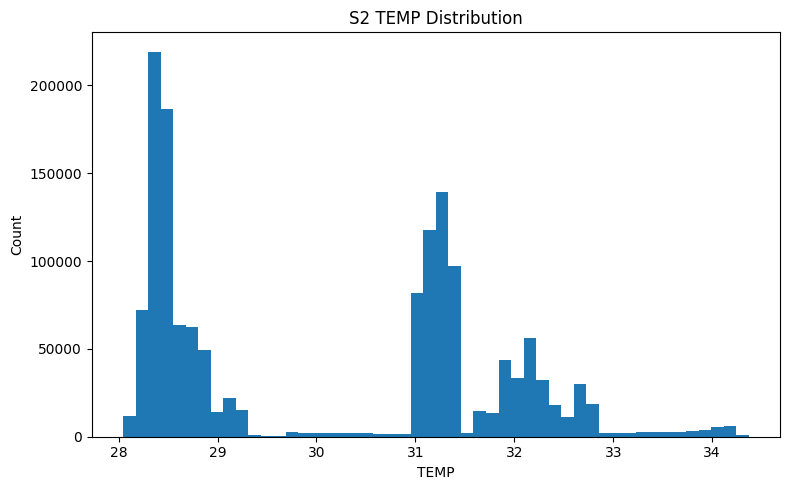

In [25]:
# TEMP 直方图
plt.figure(figsize=(8, 5))
plt.hist(df["TEMP"], bins=50)
plt.title(f"{SUBJECT} TEMP Distribution")
plt.xlabel("TEMP")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

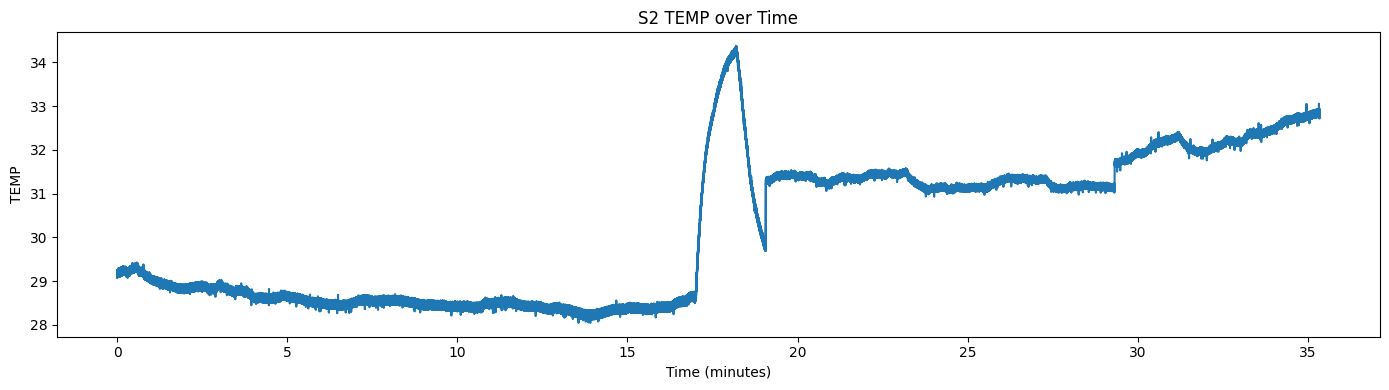

In [26]:
# TEMP 时间曲线（看整体趋势）
plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(df)) / SAMPLING_RATE / 60, df["TEMP"].values)
plt.title(f"{SUBJECT} TEMP over Time")
plt.xlabel("Time (minutes)")
plt.ylabel("TEMP")
plt.tight_layout()
plt.show()

## 第 12 部分：检查特征表

你现在看到的这个表格，就是机器学习模型真正要吃的数据。

### 请重点观察
1. 有没有很多 NaN  
2. 特征数够不够  
3. 三类标签数量是否失衡

In [27]:
print(features_df.isna().sum().sort_values(ascending=False).head(10))
print()
print(features_df["label_name"].value_counts())

hr_mean             0
hr_std              0
rr_mean_ms          0
sdnn_ms             0
rmssd_ms            0
pnn50               0
ecg_quality_mean    0
eda_tonic_mean      0
eda_tonic_std       0
eda_phasic_mean     0
dtype: int64

label_name
baseline     38
stress       20
amusement    11
Name: count, dtype: int64


In [28]:
# 简单处理缺失值：用列均值填充
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("label")

features_df[numeric_cols] = features_df[numeric_cols].fillna(features_df[numeric_cols].mean())

## 第 13 部分：先做一个最简单的 baseline

### 为什么先做最简单版本？
因为你现在在学的是流程，所以先做：
- 随机划分训练集 / 测试集
- RandomForest 分类

这不是最终科研版方案，但非常适合教学。

### 后面真正做研究时要注意什么？
真正正式一点的做法一般会考虑：
- subject-independent 验证
- LOSO（Leave-One-Subject-Out）
- 更严格的防泄漏设计

In [36]:
# ====== 确认机器学习样本划分情况 ======
from sklearn.model_selection import train_test_split

# 注意这里去掉引号，直接使用 list 变量 all_cols
X = features_df[all_cols].values
y = features_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"总窗口样本数: {len(features_df)}")
print(f"训练集样本数 (70%): {len(X_train)}")
print(f"测试集样本数 (30%): {len(X_test)}  <-- 这就是你在分类报告里看到的总数")
print("\n测试集中各类别分布 (Support):")
unique, counts = np.unique(y_test, return_counts=True)
for val, count in zip(unique, counts):
    print(f"标签 {val} ({label_map[val]}): {count}")

总窗口样本数: 69
训练集样本数 (70%): 48
测试集样本数 (30%): 21  <-- 这就是你在分类报告里看到的总数

测试集中各类别分布 (Support):
标签 1 (baseline): 12
标签 2 (stress): 6
标签 3 (amusement): 3


In [37]:
# 这里先定义三套特征：
ecg_cols = [
    "hr_mean", "hr_std", "rr_mean_ms", "sdnn_ms", "rmssd_ms", "pnn50", "ecg_quality_mean"
]

eda_cols = [
    "eda_tonic_mean", "eda_tonic_std", "eda_phasic_mean", "eda_phasic_std", "scr_peak_count", "scr_amp_mean"
]

temp_cols = [
    "temp_mean", "temp_std", "temp_min", "temp_max", "temp_slope"
]

all_cols = ecg_cols + eda_cols + temp_cols

print("ECG feature count:", len(ecg_cols))
print("EDA feature count:", len(eda_cols))
print("TEMP feature count:", len(temp_cols))
print("ALL feature count:", len(all_cols))

ECG feature count: 7
EDA feature count: 6
TEMP feature count: 5
ALL feature count: 18


In [38]:
def run_random_forest_experiment(df_features, feature_cols, random_state=42):
    X = df_features[feature_cols].values
    y = df_features["label"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=random_state,
        stratify=y
    )

    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=random_state,
        class_weight="balanced"
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    result = {
        "model": clf,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro")
    }
    return result

## 第 14 部分：分别跑 ECG-only、EDA-only、ECG+EDA+TEMP

### 为什么要拆开比较？
因为你最后常常会想知道：
- 只用 ECG 能做到什么程度？
- 只用 EDA 能做到什么程度？
- 多模态融合会不会更好？

这一步就是最简单的模态对比实验。

In [39]:
res_ecg = run_random_forest_experiment(features_df, ecg_cols)
res_eda = run_random_forest_experiment(features_df, eda_cols)
res_temp = run_random_forest_experiment(features_df, temp_cols)
res_all = run_random_forest_experiment(features_df, all_cols)

summary = pd.DataFrame([
    {"setting": "ECG-only", "accuracy": res_ecg["accuracy"], "macro_f1": res_ecg["macro_f1"]},
    {"setting": "EDA-only", "accuracy": res_eda["accuracy"], "macro_f1": res_eda["macro_f1"]},
    {"setting": "TEMP-only", "accuracy": res_temp["accuracy"], "macro_f1": res_temp["macro_f1"]},
    {"setting": "ECG+EDA+TEMP", "accuracy": res_all["accuracy"], "macro_f1": res_all["macro_f1"]},
])

summary.sort_values("macro_f1", ascending=False)

,setting,accuracy,macro_f1
3,ECG+EDA+TEMP,1.000000,1.000000
0,ECG-only,0.904762,0.907692
1,EDA-only,0.952381,0.907692
2,TEMP-only,0.904762,0.848755


## 第 15 部分：查看最好的模型结果

这里默认展示 `ECG+EDA+TEMP` 的分类报告和混淆矩阵。

In [40]:
best_res = res_all

print("Accuracy :", round(best_res["accuracy"], 4))
print("Macro-F1 :", round(best_res["macro_f1"], 4))
print()

print(classification_report(
    best_res["y_test"],
    best_res["y_pred"],
    target_names=[label_map[1], label_map[2], label_map[3]]
))

Accuracy : 1.0
Macro-F1 : 1.0

              precision    recall  f1-score   support

    baseline       1.00      1.00      1.00        12
      stress       1.00      1.00      1.00         6
   amusement       1.00      1.00      1.00         3

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



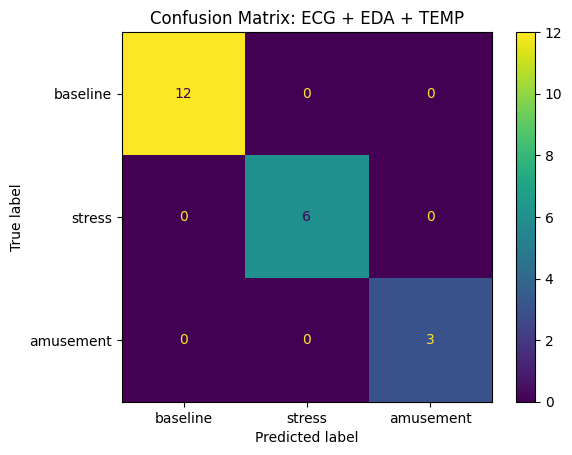

In [41]:
cm = confusion_matrix(best_res["y_test"], best_res["y_pred"], labels=[1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[label_map[1], label_map[2], label_map[3]]
)
disp.plot(values_format="d")
plt.title("Confusion Matrix: ECG + EDA + TEMP")
plt.show()

## 第 16 部分：看特征重要性

### 原理解释
RandomForest 可以给出一个粗略的“特征重要性”排序。  
这不是因果解释，但可以帮助你快速看看：

- 是 ECG 特征更有贡献？
- 还是 EDA 特征更有贡献？
- TEMP 有没有帮助？

In [42]:
importances = best_res["model"].feature_importances_
importance_df = pd.DataFrame({
    "feature": all_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
15,temp_min,0.172093
13,temp_mean,0.142342
7,eda_tonic_mean,0.125282
5,pnn50,0.109597
0,hr_mean,0.098316
16,temp_max,0.097480
2,rr_mean_ms,0.075768
4,rmssd_ms,0.057613
10,eda_phasic_std,0.028021
11,scr_peak_count,0.027730


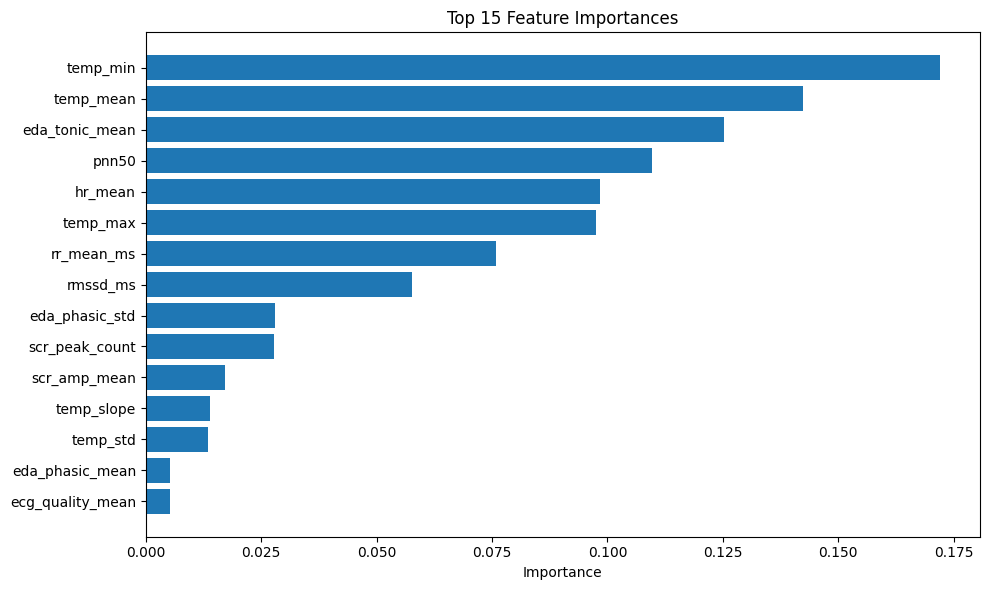

In [43]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"].head(15)[::-1], importance_df["importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# 第 17 部分：你现在应该真正理解的内容

## 1. ECG 这条线
原始 ECG  
→ 清洗  
→ 找 R 峰  
→ 得到心率 / RR 间期  
→ 得到 HRV 统计特征  
→ 进入分类器

## 2. EDA 这条线
原始 EDA  
→ 清洗  
→ 分成 tonic / phasic  
→ 找 SCR 峰  
→ 提取统计特征  
→ 进入分类器

## 3. 多模态融合这条线
ECG 特征 + EDA 特征 + TEMP 特征  
→ 拼成一个表格  
→ 训练模型  
→ 比较不同模态组合

---

# 第 18 部分：这份 notebook 的局限

这份 notebook 很适合教学，但还不是正式论文版流程。

## 局限 1：这里只是单被试教学版
真正研究里，更推荐多被试、LOSO 验证。

## 局限 2：这里只用手工特征
后面你可以继续做：
- 更多 HRV 特征
- 更多 EDA 事件特征
- 标准化 / 归一化
- 特征选择
- 深度学习

## 局限 3：这里只做基础标签窗口化
后面你还可以进一步研究：
- 如何处理标签过渡区域
- 是否只保留纯净片段
- 窗长 / 步长如何影响结果

---

# 第 19 部分：建议你接下来怎么学

### 第一步
把这份 notebook 完整跑通，并且能解释每一段代码在干什么。

### 第二步
尝试自己回答下面三个问题：
1. 为什么 ECG 要找 R 峰？
2. 为什么 EDA 要分 tonic / phasic？
3. 为什么窗口化之后才能方便做机器学习？

### 第三步
自己动手改三个超参数：
- `WINDOW_SEC`
- `STRIDE_SEC`
- `RandomForestClassifier` 的参数

### 第四步
做一个真正更像研究的小实验：
- ECG-only
- EDA-only
- ECG+EDA
- ECG+EDA+TEMP

比较哪一个最好。

---

# 第 20 部分：你可以继续扩展的方向

1. 把单被试改成多被试  
2. 加入 LOSO 验证  
3. 加入标准化  
4. 换模型：SVM / XGBoost  
5. 换数据集：DREAMER / DEAP  
6. 换成深度学习输入原始信号或 spectrogram

---

如果你想继续学，我下一步最适合做的是：

**我再给你第二份 notebook：**
> “多被试版 WESAD + LOSO 验证 + 更正式实验设计”

那一份会更像课程项目 / 小论文。